In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 1. (10 point) Betragt matricen {-}
$$
A =
\begin{bmatrix}
1 & 4 & 8 \\
1 & 4 & 8 \\
1 & 4 & 14
\end{bmatrix}
$$
Bestem en basis for søljerummet $𝑆(𝐴)$ af $𝐴$.

Det kan ses at række 1 vil gå ud med række 0 efter rækkeoperationen R1 -> R1 - R0. Derefter vil indgangene 2,0 og 2,1 gå ud efter operationen R2 -> R2 - R0. Dette efterlader pivotelementer i søjle 0 og 2. Svaret er dermed B.

## Opgave 2. (10 point) Givet basen {-}
$$
E: v_{0} =
\begin{bmatrix}
2 \\
1
\end{bmatrix}
, \, v_{1} =
\begin{bmatrix}
-1 \\
2
\end{bmatrix}
$$
or $\mathbb{R}^{2}$, hvilken af de følgende svar muligheder er koordinatvektoren $[𝑢]_{𝐸}$ for
$𝑢 =(0,1)$ mht. $𝐸$?

Definition 19.6 fra notesættet siger at koordinatvektoren med hensyn til basen kan findes ved at løse det lineær ligningssystem:
$$
A x = b, \qquad A = (v_{0}, v_{1})
$$
Denne ligning vil løses ved at reducere til echelon form og derefter lave back substitution.

In [7]:
v0 = np.array([2, 1], dtype=float)[:, np.newaxis]
v1 = np.array([-1, 2], dtype=float)[:, np.newaxis]
u = np.array([0, 1], dtype=float)[:, np.newaxis]

lign = np.column_stack((v0, v1, u))
lign

array([[ 2., -1.,  0.],
       [ 1.,  2.,  1.]])

In [8]:
lign[0] /= 2
lign

array([[ 1. , -0.5,  0. ],
       [ 1. ,  2. ,  1. ]])

In [9]:
lign[1] -= lign[0]
lign

array([[ 1. , -0.5,  0. ],
       [ 0. ,  2.5,  1. ]])

In [10]:
lign[1] /= 2.5
lign

array([[ 1. , -0.5,  0. ],
       [ 0. ,  1. ,  0.4]])

In [11]:
lign[0] -= -0.5 * lign[1]
lign

array([[1. , 0. , 0.2],
       [0. , 1. , 0.4]])

Koordinatvektoren kan nu aflæses i søjle 2. Svaret er dermed D.

## Opgave 3. (10 point) Lad $𝑉$ være vektorrummet, som består af alle differentiable funktioner $𝑓: [−1,1] \to \mathbb{R}$. {-}
Hvilke af de følgende mængder er ikke underrum af 𝑉?

I definition 12.12 i notesættet kan det ses at det kræver at $v,w \in W$ medfører $v + w \in W$ for at være et underrum. Det kan ses i svarmulighed C at $f(-1)=1$, når man summerer dem får man dog $f(-1) + f(-1) = 1 + 1 = 2$, hvilket ikke ligger i $f$. Det kan derfor ikke være et underrum og svaret må være C.

## Opgave 4. (10 point) For en symmetrisk matrix a i $\mathbb{R}^{100 \times 100}$ udregnes en tridiagonalfaktorisering a = q @ t @ q.T. Udregningen foregår via den følgende funktion {-}
```py
def tridiagonal_qt(a):
    data, s = tridiagonal_data(a)
    n, _ = a.shape
    t = np.tril(np.triu(data, -1), 1)
    q = np.eye(n)
    for j in reversed(range(n-2)):
        x = data[j+2:, [j]]
        v = np.vstack([[1], x])
        q[j+1:, j+1:] -= (s[j] * v) @ (v.T @ q[j+1:, j+1:])
    return q, t
```
Her beregner funktionen tridiagonal_data(a) en matrix data af samme
størrelse som a, og en array s med s.shape = (100,).

### (a) Angiv v.shape for v i linje 8 når j = 63. {-}

Det kan ses i linje 7, at x vil være en søjle vektor med $100 - (j + 2)$ rækker, da den får elementerne fra $j + 2$ og opefter fra data. Når $j = 63$ vil x have 35 rækker. Da v får en ekstra række fra np.vstack vil v.shape returnere (36,1).

### (b) Når v.shape = (72,1) bestem hvor mange flops bliver brugt i beregning af den nye q[j+1:, j+1:] i linje 9. {-}

Med samme logik som til x i forrige opgave kan q[j+1:, j+1:].shape beregnes til at være (72,72). Beregningen i linje 9 består da af
* En skalar-vektorprodukt af $72$ flops (s\[j] * v)
* En vektor-matrixprodukt af $2 \cdot 72 \cdot 72$ flops (v.T @ q[j+1:, j+1:])
* Et ydre produkt af $72 \cdot 72$ flops ((s\[j] * v) @ (v.T @ q[j+1:, j+1:]))
* En matrixsum af $72 \cdot 72$ flops (q[j+1:, j+1:] -= (s\[j] * v) @ (v.T @ q[j+1:, j+1:]))

In [14]:
skalar_produkt = 72
vektor_produkt = 2 * 72 * 72
ydre_produkt = 72 * 72
matrixsum = 72 * 72

print("Antallet af flops bliver da", skalar_produkt + vektor_produkt + ydre_produkt + matrixsum)

Antallet af flops bliver da 20808


## Opgave 5. (20 point) Lad de følgende vektorer i $\mathbb{R}^{6}$ være givet {-}
$$
w_{0} =
\begin{bmatrix}
1 \\
0 \\
1 \\
0 \\
1 \\
1
\end{bmatrix}
, \qquad w_{1} =
\begin{bmatrix}
0 \\
1 \\
0 \\
-1 \\
1 \\
-1
\end{bmatrix}
, \qquad w_{2} =
\begin{bmatrix}
1 \\
-1 \\
-1 \\
-1 \\
0 \\
0
\end{bmatrix}
$$

### (a) I python dan Grammatricen for $𝑤0,𝑤1,𝑤2$ og bekræft at denne sammling vektorer er ortogonal. {-}

In [17]:
# Grammatricen dannes på baggrund af afsnit 9.3 i notesættet
w0 = np.array([1, 0, 1, 0, 1, 1])[:, np.newaxis]
w1 = np.array([0, 1, 0, -1, 1, -1])[:, np.newaxis]
w2 = np.array([1, -1, -1, -1, 0, 0])[:, np.newaxis]

W = np.column_stack((w0, w1, w2))
G = W.T @ W
G

array([[4, 0, 0],
       [0, 4, 0],
       [0, 0, 4]])

Det kan ses at alle værdierne udenfor diagonalen er 0. I en grammatrix svarer det til at vektorsamlingen er ortogonal, da den $(i,j)$'te indgang er det indre produkt mellem $w_{i}$ og $w_{j}$ (jvf. afsnit 9.3 af notesættet).

### (b) Beregn projektionen $𝑃(𝑢)$ af {-}
$$
u =
\begin{bmatrix}
3 \\
4 \\
-3 \\
4 \\
0 \\
0
\end{bmatrix}
$$
til $\text{Span}\{w0,w1,w2\}$.

In [19]:
# Projektionen beregnes efter definition 8.19 i notesættet
u = np.array([3, 4, -3, 4, 0, 0])[:, np.newaxis]

P = (w0 @ w0.T) / np.linalg.norm(w0)**2 + (w1 @ w1.T) / np.linalg.norm(w1)**2 + (w2 @ w2.T) / np.linalg.norm(w2)**2
Pu = P @ u
print("Den projecerede vektor, P(u), er:\n", Pu)

Den projecerede vektor, P(u), er:
 [[-0.5]
 [ 0.5]
 [ 0.5]
 [ 0.5]
 [ 0. ]
 [ 0. ]]


### (c) Forklar hvorfor $𝑃(𝑢)$ er parallel med $𝑤_{2}$. {-}

Det kan ses at $P(u)$ er lig $-0.5 \cdot w_{2}$. Da projektionen blot er en skalering af $w_{2}$ vil den de da være parallelle.

### (d) Sæt $𝑤_{3} = 𝑢 − 𝑃(𝑢)$ og bestem en ortonormal samling $𝑣0,𝑣1,𝑣2,𝑣3$ med hvert $𝑣𝑖$ parallel med den tilsvarende $𝑤𝑖$. {-}

Man kan få en vektor til at have længden 1 ved at dele den med sin længde. Denne nye vektor vil af samme grund som i forrige opgave være parallel med den originale vektor. Den ortonormale samling kan da laves således

In [20]:
w3 = u - Pu

# længden af en vektor svarer til 2-normen til den
v0 = w0 / np.linalg.norm(w0, 2)
v1 = w1 / np.linalg.norm(w1, 2)
v2 = w2 / np.linalg.norm(w2, 2)
v3 = w3 / np.linalg.norm(w3, 2)
V = np.column_stack((v0, v1, v2, v3))

print("Den ortonormale samling bliver da \n", V)

Den ortonormale samling bliver da 
 [[ 0.5  0.   0.5  0.5]
 [ 0.   0.5 -0.5  0.5]
 [ 0.5  0.  -0.5 -0.5]
 [ 0.  -0.5 -0.5  0.5]
 [ 0.5  0.5  0.   0. ]
 [ 0.5 -0.5  0.   0. ]]


## Opgave 6. (20 point) Betragt de følgende datapunkter {-}

| s   | -3.0 | -2.0 | -1.0 | 0.0 | 1.0 | 1.1 | 2.0 | 3.0 |
| --- |  --- |  --- |  --- | --- | --- | --- | --- | --- |
| h   | -3.1 |  2.9 |  5.1 | 3.5 | 4.0 | 3.2 | 5.0 | 5.8 |

Der ønskes et polynomium $𝑝𝑠^{3} +𝑞𝑠^{2} +𝑟𝑠 +𝑐$, der går igennem punkterne.

### (a) Ved hjælp af funktionen np.vander(...) opstil et lineært ligningssystem af formen $𝐴𝑣 = 𝑏$, som svarer til problemstillingen. Angiv størrelsen af $𝐴$, $𝑣$ og $𝑏$ og forklar hvorfor der kan ikke forventes en eksakt løsning. {-}

In [22]:
# Da koefficienterne i polynomiet er baseret på s, 
# vil datapunkterne for s svare til koefficientmatricen
s_data = np.array([-3.0, -2.0, -1.0, 0.0, 1.0, 1.1, 2.0, 3.0])
A = np.vander(s_data, 4)    # np.vander for potenserne
print("Størrelsen af A er:", A.shape)

# h må da være målet som polynomiet skal ramme for hver s
b = np.array([-3.1, 2.9, 5.1, 3.5, 4.0, 3.2, 5.0, 5.8])[:, np.newaxis]
print("Størrelsen af b er:", b.shape)

Størrelsen af A er: (8, 4)
Størrelsen af b er: (8, 1)


Vektoren med variablerne kan ikke opstilles i python på samme måde, men for at passe med dimensionerne i A vides det at den er i $\mathbb{R}^{4}$. Den kan dog opskrives symbolsk således:
$$
v =
\begin{bmatrix}
p \\
q \\
r \\
c
\end{bmatrix}
$$

Det kan ses at der er flere rækker en søjler i koefficientmatricen, hvilket vil sige at man ikke kan forvente en eksakt løsning, som rammer alle datapunkter med kun et tredjegradspolynomium. 

### (b) Ved brug af en tynd 𝑄𝑅-dekomponering konstrueret via den forbedrede Gram-Schmidt proces, bestem i python den mindste kvadraters løsning til systemet $𝐴𝑣 = 𝑏$. {-}

In [29]:
# Fra afsnit 15.3 i notesættet
def forbedret_gram_schmidt(a):
    _, k = a.shape
    q = np.copy(a)
    r = np.zeros((k, k))
    for i in range(k):
        r[i, i] = np.linalg.norm(q[:, i])
        q[:, i] /= r[i, i]
        r[[i], i+1:] = q[:, [i]].T @ q[:, i+1:]
        q[:, i+1:] -= q[:, [i]] @ r[[i], i+1:]
    return q, r

# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

In [31]:
# Resultaterne fra QR-dekomponeringen samt b indsættes i ligning 16.4 fra notesættet
q, r = forbedret_gram_schmidt(A)
QTb = q.T @ b
v = back_subs(r, QTb)
v

array([[ 0.23574465],
       [-0.3125912 ],
       [-0.60764437],
       [ 4.48567771]])

### (c) Giv en python plot af datapunkterne og polynomiet bestemt af din løsning. {-}

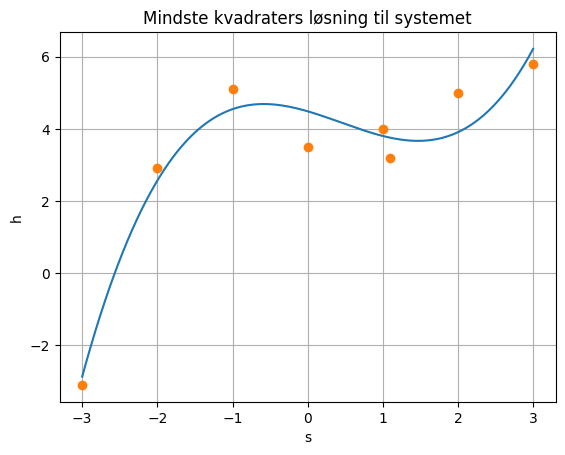

In [34]:
s = np.linspace(-3, 3, 200)
h = v[0]*s**3 + v[1]*s**2 + v[2]*s + v[3]

fig, ax = plt.subplots()
ax.plot(s, h)
ax.plot(s_data, b, "o")
ax.set_xlabel('s')
ax.set_ylabel('h')
ax.set_title('Mindste kvadraters løsning til systemet')
ax.grid()

### (d) Brug python til at bestemme singulærværdierne af $𝐴$ og konditionstallet for $𝐴$. Giv desuden en øvre grænse for konditionstallet $𝜅$ for beregning, som funktion af $𝐴$, af den mindste kvadraters løsning $𝑣$ til $𝐴𝑣 = 𝑏$. {-}

In [36]:
u, s, vt = np.linalg.svd(A)

# ligning 11.10
kA = s[0] / s[-1]

# ligning 17.1 siger at Av = Pb, så vinklen mellem Av og b kan findes således
theta = np.arccos(np.linalg.norm(A @ v, 2) / np.linalg.norm(b, 2))

eta = s[0] * (np.linalg.norm(v, 2) / np.linalg.norm(A @ v, 2))

# ligning 17.2
kappa = kA + (kA**2 * np.abs(np.tan(theta))) / eta

print(f"singulærværdierne for A = {s}\nκ(A) = {kA} \nDen øvre grænse for konditionstallet er κ = {kappa}")

singulærværdierne for A = [40.17926503 14.20810991  2.2368785   1.78838194]
κ(A) = 22.466825556585317 
Den øvre grænse for konditionstallet er κ = 27.381030968521376


## Opgave 7. (20 point) Lad matricen 𝐴 være givet ved {-}
$$
\begin{bmatrix}
2 & 2 & -1 \\
0 & 3 & 0 \\
1 & 0 & 2
\end{bmatrix}
$$
I det følgende må der ikke bruges funktioner som np.linalg.eig eller tilsvarende computer algebra funktioner.

### (a) Vis at $𝑣_{0} = (1,1,1)$ er en egenvektor for $𝐴$ og bestem den tilhørende egenværdi $𝜆_{0}$. {-}

Ifølge definition 21.1 skal der være en $\lambda$ der opfylder $Av_{0} = \lambda_{0} v_{0}$ før $v_{0}$ kan være en egenvektor for $A$. Når venstre siden udregnes fås følgende:
$$
Av_{1} =
\begin{bmatrix}
2 & 2 & -1 \\
0 & 3 & 0 \\
1 & 0 & 2
\end{bmatrix}
\begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
3 \\
3 \\
3
\end{bmatrix}
$$
Dette kan reproduceres på højre side ved at sætte $\lambda_{0}=3$ således at
$$
\lambda_{0}v_{0} =
3
\begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}
=
\begin{bmatrix}
3 \\
3 \\
3
\end{bmatrix}
$$
$v_{0}$ er da en egenvektor for $A$ til egenværdien $\lambda_{0} = 3$.

### (b) Vis at $𝜆_{1} = 2 + 𝑖$ er en egenværdi for $𝐴$ og bestem en tilhørende egenvektor $𝑣_{1}$. {-}

Det karakteristiske polynomium kan sættes op som vist i afsnit 21.5 af notesættet.
\begin{align*}
\det(A-\lambda I_{3}) &= \det \left( \begin{bmatrix}2-\lambda & 2 & -1 \\ 0 & 3-\lambda & 0 \\ 1 & 0 & 2-\lambda \end{bmatrix}\right) \\ 
&= (2-\lambda)\det \left(\begin{bmatrix}3-\lambda & 0 \\0 & 2-\lambda\end{bmatrix}\right)-2\det \left(\begin{bmatrix}0 & 0 \\1 & 2-\lambda\end{bmatrix}\right)-1\det \left(\begin{bmatrix}0 & 3-\lambda \\1 & 0\end{bmatrix}\right) \\ 
&= (2-\lambda)((3-\lambda)(2-\lambda)-0\cdot0)-2(0\cdot(2-\lambda)-0\cdot1)-1(0\cdot0-(3-\lambda)\cdot1) \\
&= (2-\lambda)(6-3\lambda-2\lambda+\lambda^{2})-2(0)-1(-3+\lambda) \\
&= 12-10\lambda+2\lambda^{2}-6\lambda+5\lambda^{2}-\lambda^{3}+3-\lambda \\
&= -\lambda^{3}+7\lambda^{2}-17\lambda+15
\end{align*}

Da det vides at 3 er en egenværdi for A kan polynomiet deles med $(3 - \lambda)$ gennem syntetisk division.

![division](C:/Users/henri/OneDrive%20-%20Aarhus%20universitet/2.%20Semester/Numerisk%20Lineær%20Algebra/Gamle%20Eksamener/F23.png)

Dette leder til andengradspolynomiet
$$
-\lambda^{2} + 4 \lambda - 5
$$

De resterende egenværdier bliver da
$$
\lambda_{1}, \lambda_{2} = \frac{-4 \pm \sqrt{16 - 20}}{-2} = \frac{-4 \pm \sqrt{-4}}{-2} = \frac{4 \pm 2i}{2} = 2 \pm i
$$

Nu når $\lambda_{1} = 2+i$ er godkendt kan dens tilhørende egenvektor bestemmes ved at løse ligningen
$(A - \lambda_{1}I_{3}) v_{1} = 0$.
$$
A - \lambda_{1} I_{3} =
\begin{bmatrix}
2 - (2+i) & 2 & -1 \\
0 & 3 - (2+i) & 0 \\
1 & 0 & 2 - (2+i)
\end{bmatrix}
=
\begin{bmatrix}
-i & 2 & -1 \\
0 & 1-i & 0 \\
1 & 0 & -i
\end{bmatrix}
\sim_{R_{0} \to R_{0} / -i}
\begin{bmatrix}
1 & 2i & -i \\
0 & 1-i & 0 \\
1 & 0 & -i
\end{bmatrix}
$$
Følgende ligninger skal løses
$$
\begin{cases}
x + 2iy - iz = 0 \\
(1-i)y = 0 \\
x - iz = 0
\end{cases}
$$
Den eneste måde den midterste ligning kan løses er hvis $y=0$. Derefter kan det med den sidste ligning ses at $x = iz$.

En løsning til egenvektoren til $\lambda_{1}$ kan derfor være
$$
v_{1} = 
\begin{bmatrix}
i \\
0 \\
1
\end{bmatrix}
$$

### (c) Fra dele (a) og (b) bestem en diagonal matrix $Λ$ og en invertibel matrix $𝑉$ således at {-}
$$
A = V \Lambda V^{-1}
$$

Gøres det samme med sidste egenværdi $\lambda_{2}=2-i$, kan sidste egenvektor bestemmes.
$(A - \lambda_{2}I_{3}) v_{2} = 0$.
$$
A - \lambda_{2} I_{3} =
\begin{bmatrix}
2 - (2-i) & 2 & -1 \\
0 & 3 - (2-i) & 0 \\
1 & 0 & 2 - (2-i)
\end{bmatrix}
=
\begin{bmatrix}
i & 2 & -1 \\
0 & 1+i & 0 \\
1 & 0 & i
\end{bmatrix}
\sim_{R_{0} \to R_{0} / i}
\begin{bmatrix}
1 & -2i & i \\
0 & 1+i & 0 \\
1 & 0 & i
\end{bmatrix}
$$
Følgende ligninger skal løses
$$
\begin{cases}
x - 2iy + iz = 0 \\
(1+i)y = 0 \\
x + iz = 0
\end{cases}
$$
Igen skal $y=0$. Denne gang viser sidste ligning dog $x = -iz$.

En løsning til egenvektoren til $\lambda_{2}$ kan derfor være
$$
v_{2} = 
\begin{bmatrix}
-i \\
0 \\
1
\end{bmatrix}
$$

Gennem proposition 21.6 vides det at enhver matrix med en basis af egenvektorer kan skrives op på den ønskede form en en invertibel matrix $V$ bestående af egenvektorer og en diagonalmatrix $\Lambda$ bestående af egenværdier. Matricerne kommer da til at være følgende:
$$
V =
\begin{bmatrix}
3 & i & -i \\
3 & 0 & 0 \\
3 & 1 & 1
\end{bmatrix}
, \qquad \Lambda =
\begin{bmatrix}
3 & 0 & 0 \\
0 & 2 + i & 0 \\
0 & 0 & 2 - i
\end{bmatrix}
$$

### (d) Bestem løsningen $𝑦(𝑡) = (𝑦_{0}(𝑡),𝑦_{1}(𝑡),𝑦_{2}(𝑡))$ til systemet {-}
$$
y'(t) = Ay(t)
$$
med startbetingelsen $𝑦(0) = (1,0,0)$ og plot funktionen $e^{−2t}𝑦_{0}(𝑡)$.

Ud fra proposition vides det at løsningen blot kan findes som et lineært ligningssystem, hvor koefficientmatricen er egenvektorerne mens variablerne er konstanterne $c_{i}$ i løsningen og produktet af koefficientmatricen og variablerne skal give startbetingelsen. Ligningssystemet kan da løses gennem rækkeoperationer:
$$
\begin{align*}
\begin{bmatrix}
3 & i & -i & | & 1 \\
3 & 0 & 0 & | & 0 \\
3 & 1 & 1 & | & 0
\end{bmatrix}
&\sim_{R_{1} \leftrightarrow R_{2}}
\begin{bmatrix}
3 & i & -i & | & 1 \\
3 & 1 & 1 & | & 0 \\
3 & 0 & 0 & | & 0
\end{bmatrix}\\
&\sim_{R_{2} \to R_{2} - R_{1}}
\begin{bmatrix}
3 & i & -i & | & 1 \\
3 & 1 & 1 & | & 0 \\
0 & -1 & -1 & | & 0
\end{bmatrix}\\
&\sim_{R_{1} \to R_{1} - R_{0}}
\begin{bmatrix}
3 & i & -i & | & 1 \\
0 & 1-i & 1+i & | & -1 \\
0 & -1 & -1 & | & 0
\end{bmatrix}\\
&\sim_{R_{0} \to R_{0} \cdot \frac{1}{3}}
\begin{bmatrix}
1 & \frac{1}{3}i & -\frac{1}{3}i & | & \frac{1}{3} \\
0 & 1-i & 1+i & | & -1 \\
0 & -1 & -1 & | & 0
\end{bmatrix}\\
&\sim_{R_{1} \to R_{1} \cdot \frac{1}{1-i}}
\begin{bmatrix}
1 & \frac{1}{3}i & -\frac{1}{3}i & | & \frac{1}{3} \\
0 & 1 & i & | & -\frac{1}{2}-\frac{1}{2}i \\
0 & -1 & -1 & | & 0
\end{bmatrix}\\
&\sim_{R_{2} \to R_{2} + R_{1}}
\begin{bmatrix}
1 & \frac{1}{3}i & -\frac{1}{3}i & | & \frac{1}{3} \\
0 & 1 & i & | & -\frac{1}{2}-\frac{1}{2}i \\
0 & 0 & -1+i & | & -\frac{1}{2}-\frac{1}{2}i
\end{bmatrix}\\
&\sim_{R_{2} \to R_{2} \cdot \frac{1}{-1+i}}
\begin{bmatrix}
1 & \frac{1}{3}i & -\frac{1}{3}i & | & \frac{1}{3} \\
0 & 1 & i & | & -\frac{1}{2}-\frac{1}{2}i \\
0 & 0 & 1 & | & +\frac{1}{2}i
\end{bmatrix}\\
&\sim_{R_{1} \to R_{1} - iR_{2}}
\begin{bmatrix}
1 & \frac{1}{3}i & -\frac{1}{3}i & | & \frac{1}{3} \\
0 & 1 & 0 & | & -1-\frac{1}{2}i \\
0 & 0 & 1 & | & \frac{1}{2}i
\end{bmatrix}\\
&\sim_{R_{0} \to R_{0} + \frac{1}{3}iR_{2}}
\begin{bmatrix}
1 & \frac{1}{3}i & 0 & | & \frac{1}{3}+\frac{1}{6}i \\
0 & 1 & 0 & | & -1-\frac{1}{2}i \\
0 & 0 & 1 & | & \frac{1}{2}i
\end{bmatrix}\\
&\sim_{R_{0} \to R_{0} - \frac{1}{3}iR_{1}}
\begin{bmatrix}
1 & 0 & 0 & | & \frac{1}{6}+\frac{1}{2}i \\
0 & 1 & 0 & | & -1-\frac{1}{2}i \\
0 & 0 & 1 & | & \frac{1}{2}i
\end{bmatrix}
\end{align*}
$$

Løsningen til systemet bliver dermed:
$$
y(t) = 
\left(\frac{1}{6} + \frac{1}{2}i\right) \begin{bmatrix}
3 \\
3 \\
3
\end{bmatrix} e^{3t} +
\left( - 1 - \frac{1}{2}i \right)
\begin{bmatrix}
i \\
0 \\
1
\end{bmatrix} e^{(2+i)t} +
\left( \frac{1}{2}i \right)
\begin{bmatrix}
-i \\
0 \\
1
\end{bmatrix} e^{(2-i)t}
$$

In [79]:
# Fra eksempel 22.5 i notesættet
def sol_c(r0, r1, v_c, lambda_c, t):
    w = v_c.real
    z = v_c.imag
    v = np.hstack([w, z])
    a = lambda_c.real
    b = lambda_c.imag
    r = np.array([r0, r1])[:, np.newaxis]
    c = np.linalg.solve(v, r)
    return (c[0] * np.exp(a*t) * (np.cos(b*t) 
            * w - np.sin(b*t) * z) 
            + c[1] * np.exp(a*t) 
            * (np.sin(b*t) * w + np.cos(b*t) * z))

HAVDE AFLEVERET HER OG IKKE NÅÊT DEN HER OPGAVE (havde 10 min tilbage)

LinAlgError: Last 2 dimensions of the array must be square

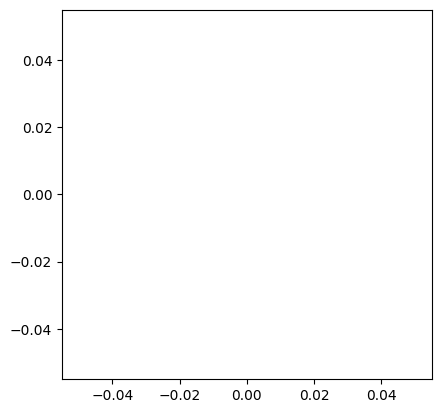

In [82]:
t = np.linspace(0, 5, 1000)

c0 = 1/6 + 0.5j
v0 = np.array([3,3,3])[:, np.newaxis]
lambda0 = 3
y0 = c0 * v0 * np.exp(lambda0*t)

marks = dict(marker='o', markevery=20, markersize=3)

fig, ax = plt.subplots()
ax.plot()
ax.set_aspect('equal')
for s in np.linspace(0.5, 3, 6):
    ax.plot(*sol_c(s, 0, v0, lambda0, t), marks)
ax.set_xlabel('$y_{0}$')
ax.set_ylabel('$y_{1}$')
